Day 9: Business Forecasting

Total rows: 20
Past rows: 14
Recent rows: 6


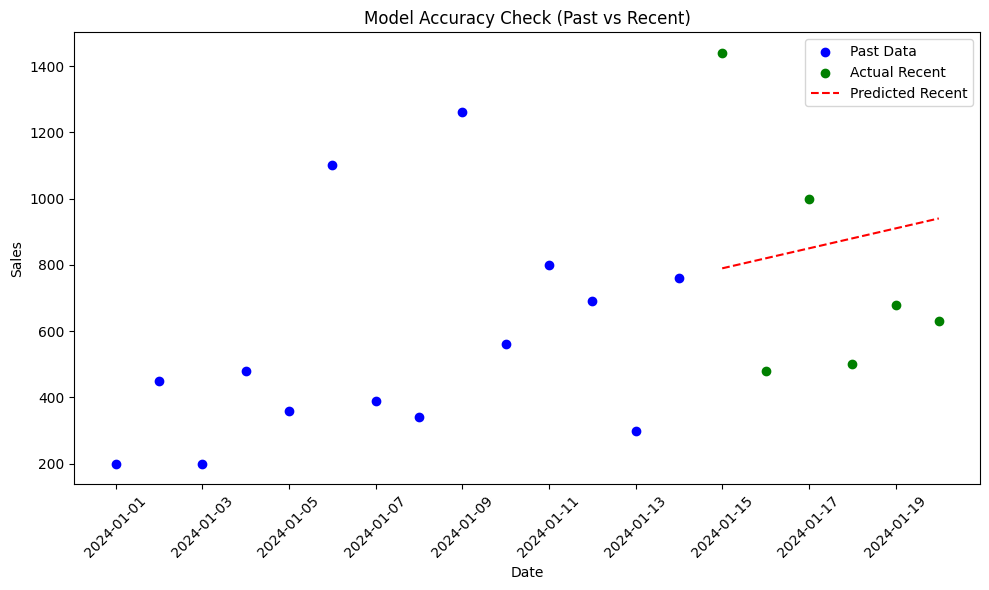

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/HP/Downloads/data_analyst/day9/sales_cleaned.csv")

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Sales'] = df['Price'] * df['Quantity']

df = df.sort_values('Date')

df['Date_Ordinal'] = df['Date'].map(dt.datetime.toordinal)

split_index = int(len(df) * 0.7)

past = df.iloc[:split_index]
recent = df.iloc[split_index:]

print("Total rows:", len(df))
print("Past rows:", len(past))
print("Recent rows:", len(recent))

X_train = past[['Date_Ordinal']]
y_train = past['Sales']

model = LinearRegression()
model.fit(X_train, y_train)

X_test = recent[['Date_Ordinal']]
predictions = model.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(past['Date'], past['Sales'], color='blue', label='Past Data')
plt.scatter(recent['Date'], recent['Sales'], color='green', label='Actual Recent')

plt.plot(recent['Date'], predictions, color='red', linestyle='--', label='Predicted Recent')

plt.title("Model Accuracy Check (Past vs Recent)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Reflection

A simple Linear Forecast may fail during December or holiday sales because it only captures long-term trends and assumes a steady pattern over time.

However, real-world sales often include seasonality, where demand increases or decreases during specific periods such as holidays, festivals, or year-end sales. For example, during December, sales may spike due to holiday shopping, which is not part of the regular trend.

Linear models cannot capture these sudden seasonal spikes, leading to inaccurate predictions. Therefore, more advanced models that consider seasonality are required for such scenarios.